# Yield Curve Forecasting

Nelson-Siegel baseline fit, RUB–CNY cross-currency spreads, and evaluation.

**Data required:** Run the data pipeline first so the DB has:
- **RU yields:** `cbr_gcurve` and/or `russian_bond_yields`
- **CN yields:** `chinese_bond_yields` (manual ChinaBond files in `src/data_manual/` or pipeline)
- **FRED (optional):** Set `FRED_API_KEY` and run pipeline for `global_indicators` (US rates, oil)

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.forecasting.loaders import load_russian_yield_curve, load_chinese_yield_curve
try:
    from src.forecasting.loaders import load_global_indicators
except ImportError:
    def load_global_indicators(start_date=None, end_date=None):
        """Fallback: load global_indicators from DB if load_global_indicators not in loaders."""
        try:
            from src.database import DatabaseManager
            from config import DB_PATH
            db = DatabaseManager(str(DB_PATH))
            df = db.load_dataframe("global_indicators")
            if df.empty or "date" not in df.columns:
                return pd.DataFrame()
            df = df.copy()
            df["date"] = pd.to_datetime(df["date"])
            if start_date:
                df = df[df["date"] >= pd.to_datetime(start_date)]
            if end_date:
                df = df[df["date"] <= pd.to_datetime(end_date)]
            return df.set_index("date")
        except Exception:
            return pd.DataFrame()
from src.forecasting.ns_baseline import compute_residuals, get_fitted_curves
import importlib
import src.forecasting.cross_currency as _cc
importlib.reload(_cc)
from src.forecasting.cross_currency import build_spreads, flag_abnormal_spreads
from src.forecasting.evaluate import evaluate_ns_fit, evaluate_spreads
from config import PROJECT_ROOT
import os

FIG_DIR = str(PROJECT_ROOT / "project report" / "graphics")
os.makedirs(FIG_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

# NS decay parameter (overwritten by hyperparameter search in §2a)
LAM_BEST_RU = 2.0
LAM_BEST_CN = 2.0
print('Setup complete.')

KeyboardInterrupt: 

## 1. Load Yield Curves

In [ ]:
# Optional: restrict date range
START_DATE = None  # e.g. '2019-01-01'
END_DATE = None   # e.g. '2025-12-31'

ru_yields = load_russian_yield_curve(start_date=START_DATE, end_date=END_DATE)
cn_yields = load_chinese_yield_curve(start_date=START_DATE, end_date=END_DATE)
glob_ind = load_global_indicators(start_date=START_DATE, end_date=END_DATE)  # FRED: DGS10, oil, etc.
ru_residuals = pd.DataFrame()  # filled by NS fit cell
cn_residuals = pd.DataFrame()

print(f'RU: {len(ru_yields)} rows, {list(ru_yields.columns)}')
print(f'CN: {len(cn_yields)} rows, {list(cn_yields.columns)}')
print(f'FRED (global): {len(glob_ind)} rows, {list(glob_ind.columns) if not glob_ind.empty else []}')

if ru_yields.empty and cn_yields.empty:
    print('No yield data. Run the data pipeline first.')

RU: 219 rows, ['RU_1Y', 'RU_3Y', 'RU_5Y', 'RU_10Y', 'RU_15Y', 'RU_20Y', 'RU_2Y', 'RU_7Y']
CN: 96 rows, ['CN_10Y', 'CN_15Y', 'CN_1Y', 'CN_20Y', 'CN_2Y', 'CN_30Y', 'CN_3M', 'CN_3Y', 'CN_5Y', 'CN_6M', 'CN_7Y', 'CN_9M']
FRED (global): 134 rows, ['DGS10', 'DGS2', 'FEDFUNDS', 'DCOILBRENTEU', 'DTWEXBGS', 'IPMAN', 'UMCSENT']


### 1b. FRED global indicators (US rates, oil)

Optional context: US 10Y (DGS10) and Brent oil for cross-currency interpretation.

### 2a. Hyperparameter search: decay parameter λ

The Nelson-Siegel model has one main hyperparameter: **λ (lambda)**, the decay parameter that controls where the curvature factor peaks. Typical values in the literature range from 1.0 to 4.0. We grid-search over λ to minimize mean RMSE.

Best λ (by mean RMSE):
  RU: λ = 3.50  (RMSE mean = 0.2236)
  CN: λ = 2.50  (RMSE mean = 0.0634)


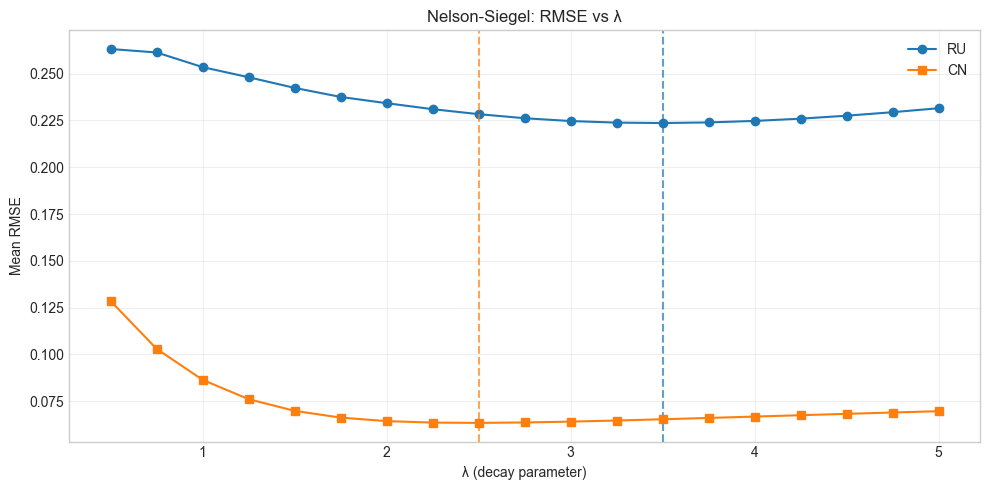

In [ ]:
# Grid search over Nelson-Siegel decay parameter λ
# Typical range: 0.5–5.0; literature often uses 1.5–3.5
LAM_GRID = np.linspace(0.5, 5.0, 19)  # 0.5, 0.75, 1.0, ..., 5.0

ru_results = []  # (lam, MAE_mean, RMSE_mean)
cn_results = []

for lam in LAM_GRID:
    if not ru_yields.empty:
        ru_fit = get_fitted_curves(ru_yields, lam=lam)
        ru_res = compute_residuals(ru_yields, lam=lam)
        ru_ev = evaluate_ns_fit(ru_yields, ru_fit, ru_res)
        ru_results.append((lam, ru_ev.get("overall", {}).get("MAE_mean", np.nan),
                          ru_ev.get("overall", {}).get("RMSE_mean", np.nan)))
    if not cn_yields.empty:
        cn_fit = get_fitted_curves(cn_yields, lam=lam)
        cn_res = compute_residuals(cn_yields, lam=lam)
        cn_ev = evaluate_ns_fit(cn_yields, cn_fit, cn_res)
        cn_results.append((lam, cn_ev.get("overall", {}).get("MAE_mean", np.nan),
                          cn_ev.get("overall", {}).get("RMSE_mean", np.nan)))

# Best λ by mean RMSE (primary metric for curve fit)
LAM_BEST_RU = float(LAM_GRID[np.nanargmin([r[2] for r in ru_results])]) if ru_results else 2.0
LAM_BEST_CN = float(LAM_GRID[np.nanargmin([r[2] for r in cn_results])]) if cn_results else 2.0

print("Best λ (by mean RMSE):")
if ru_results:
    print(f"  RU: λ = {LAM_BEST_RU:.2f}  (RMSE mean = {min(r[2] for r in ru_results):.4f})")
if cn_results:
    print(f"  CN: λ = {LAM_BEST_CN:.2f}  (RMSE mean = {min(r[2] for r in cn_results):.4f})")

# Plot RMSE vs λ
fig, ax = plt.subplots(figsize=(10, 5))
if ru_results:
    lams_ru = [r[0] for r in ru_results]
    rmse_ru = [r[2] for r in ru_results]
    ax.plot(lams_ru, rmse_ru, "o-", label="RU", color="C0")
    ax.axvline(LAM_BEST_RU, color="C0", linestyle="--", alpha=0.7)
if cn_results:
    lams_cn = [r[0] for r in cn_results]
    rmse_cn = [r[2] for r in cn_results]
    ax.plot(lams_cn, rmse_cn, "s-", label="CN", color="C1")
    ax.axvline(LAM_BEST_CN, color="C1", linestyle="--", alpha=0.7)
ax.set_xlabel("λ (decay parameter)")
ax.set_ylabel("Mean RMSE")
ax.set_title("Nelson-Siegel: RMSE vs λ")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

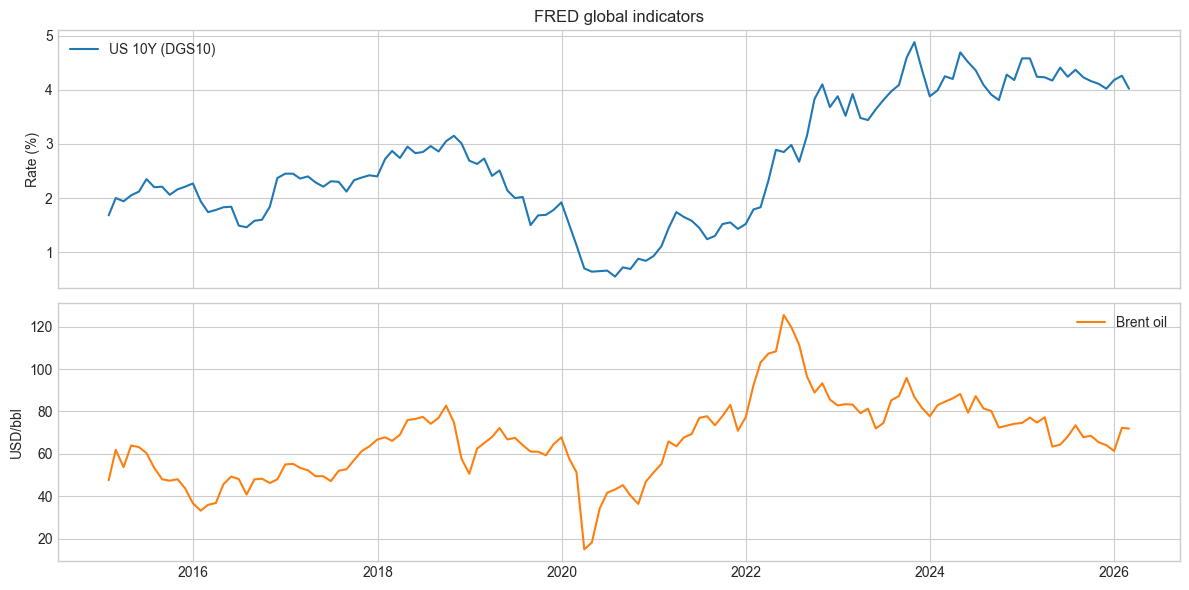

In [ ]:
if not glob_ind.empty:
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    if 'DGS10' in glob_ind.columns:
        s = glob_ind['DGS10'].dropna()
        if len(s) > 0:
            axes[0].plot(s.index, s.values, label='US 10Y (DGS10)', color='C0')
    if 'DCOILBRENTEU' in glob_ind.columns:
        s = glob_ind['DCOILBRENTEU'].dropna()
        if len(s) > 0:
            axes[1].plot(s.index, s.values, label='Brent oil', color='C1')
    axes[0].set_ylabel('Rate (%)')
    axes[1].set_ylabel('USD/bbl')
    axes[0].legend()
    axes[1].legend()
    axes[0].set_title('FRED global indicators')
    plt.tight_layout()
    plt.show()
else:
    print('No FRED global_indicators in DB. Run pipeline with FRED_API_KEY set.')

## 2. Nelson-Siegel Baseline Fit

In [ ]:
if not ru_yields.empty:
    ru_fitted = get_fitted_curves(ru_yields, lam=LAM_BEST_RU)
    ru_residuals = compute_residuals(ru_yields, lam=LAM_BEST_RU)
    ru_eval = evaluate_ns_fit(ru_yields, ru_fitted, ru_residuals)
    print('RU Nelson-Siegel:')
    print(f"  MAE mean: {ru_eval.get('overall', {}).get('MAE_mean', 'N/A')}")
    print(f"  RMSE mean: {ru_eval.get('overall', {}).get('RMSE_mean', 'N/A')}")
    display(pd.DataFrame(ru_eval.get('by_maturity', {})).T)
else:
    print('No RU data.')

RU Nelson-Siegel:
  MAE mean: 0.141645983571725
  RMSE mean: 0.2236232163546423


,MAE,RMSE
RU_3Y,0.081615,0.133504
RU_5Y,0.139110,0.198555
RU_10Y,0.291288,0.471844
RU_15Y,0.071891,0.102649
RU_20Y,0.112567,0.223781
RU_2Y,0.054532,0.084220
RU_7Y,0.240518,0.350810


In [ ]:
if not cn_yields.empty:
    cn_fitted = get_fitted_curves(cn_yields, lam=LAM_BEST_CN)
    cn_residuals = compute_residuals(cn_yields, lam=LAM_BEST_CN)
    cn_eval = evaluate_ns_fit(cn_yields, cn_fitted, cn_residuals)
    print('CN Nelson-Siegel:')
    print(f"  MAE mean: {cn_eval.get('overall', {}).get('MAE_mean', 'N/A')}")
    print(f"  RMSE mean: {cn_eval.get('overall', {}).get('RMSE_mean', 'N/A')}")
    display(pd.DataFrame(cn_eval.get('by_maturity', {})).T)
else:
    print('No CN data.')

CN Nelson-Siegel:
  MAE mean: 0.049673479592486754
  RMSE mean: 0.06341907131176891


,MAE,RMSE
CN_10Y,0.111291,0.126821
CN_15Y,0.024001,0.028821
CN_1Y,0.058818,0.079512
CN_20Y,0.032194,0.041196
CN_2Y,0.056278,0.068734
CN_30Y,0.070720,0.081045
CN_3M,0.073425,0.099116
CN_3Y,0.034416,0.043216
CN_5Y,0.025178,0.032098
CN_6M,0.038508,0.058253


## 3. Cross-Currency Spreads (RUB–CNY)

In [ ]:
spreads = build_spreads(ru_yields, cn_yields)
if spreads.empty:
    from src.forecasting.cross_currency import _common_maturities
    maturities = _common_maturities(ru_yields.columns.tolist(), cn_yields.columns.tolist())
    print('No spreads. Debug: common_maturities=', maturities)
    print('RU date range:', ru_yields.index.min(), 'to', ru_yields.index.max())
    print('CN date range:', cn_yields.index.min(), 'to', cn_yields.index.max())
else:
    flagged = flag_abnormal_spreads(spreads, z_threshold=2.0)
    spread_eval = evaluate_spreads(spreads, flagged)
    print('Spread stats:')
    display(pd.DataFrame(spread_eval.get('spread_stats', {})).T)
    print('Abnormal counts (Z>2):')
    display(pd.Series(spread_eval.get('abnormal_counts', {})))
    spreads.plot(title='RUB–CNY yield spreads by maturity')
    plt.tight_layout()
    plt.show()

NameError: name 'build_spreads' is not defined

## 4. Residual Plots (RU)

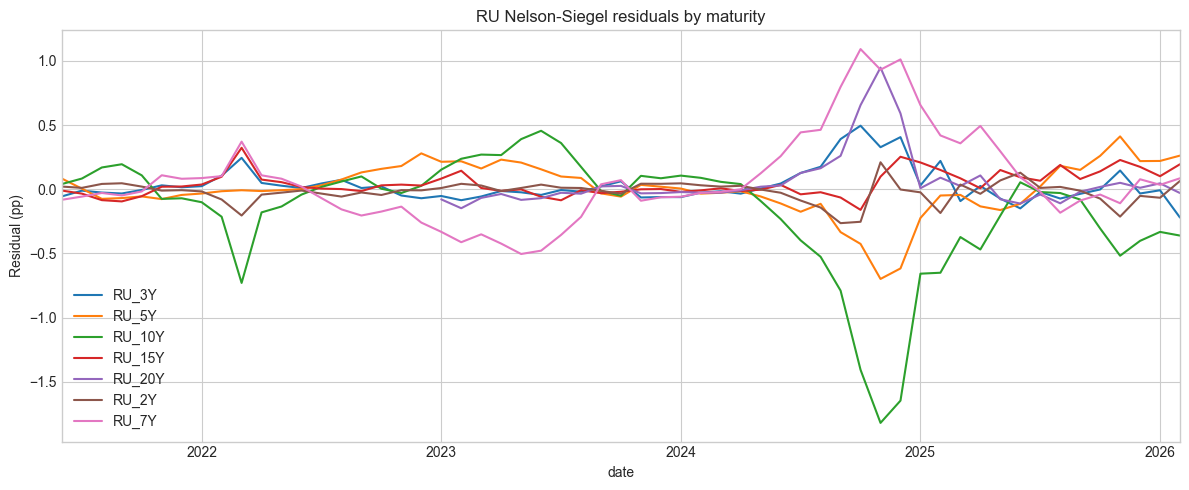

In [ ]:
if ru_yields.empty:
    print('No RU yield data. Run the load cell (2) first.')
else:
    if ru_residuals.empty:
        ru_residuals = compute_residuals(ru_yields, lam=LAM_BEST_RU)
        print('RU residuals computed for plotting (run the "Nelson-Siegel Baseline Fit" cell above for full MAE/RMSE).')
    if not ru_residuals.empty:
        to_plot = ru_residuals.dropna(how='all', axis=1).dropna(how='all')
        if to_plot.empty or to_plot.shape[1] == 0:
            print('No plottable RU residuals (all columns NaN). Ensure NS fit ran successfully.')
        else:
            to_plot.plot(title='RU Nelson-Siegel residuals by maturity', legend=True)
            plt.ylabel('Residual (pp)')
            plt.tight_layout()
            plt.show()
    else:
        print('Could not compute RU residuals (need enough yield columns/maturities).')